In [19]:
import sys
print(sys.executable)

s:\project\greenpulse\backend\.venv\Scripts\python.exe


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
# This assumes your CSV is in the 'data' folder
df = pd.read_csv('../data/crop-yield.csv')

# 2. Basic Cleanup
# Often these CSVs have an extra 'Unnamed' column, let's remove it if it's there
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

print("Phase 1: Data successfully loaded into the 'df' variable.")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")

Phase 1: Data successfully loaded into the 'df' variable.
Total Rows: 28242, Total Columns: 7


In [21]:
# Check data types and look for missing values
print("--- Column Data Types ---")
print(df.dtypes)

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

# Look at the first 5 rows to see how the text and numbers look
df.head()

--- Column Data Types ---
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

--- Missing Values Check ---
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [22]:
# Show statistical distribution of numerical columns
df.describe()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


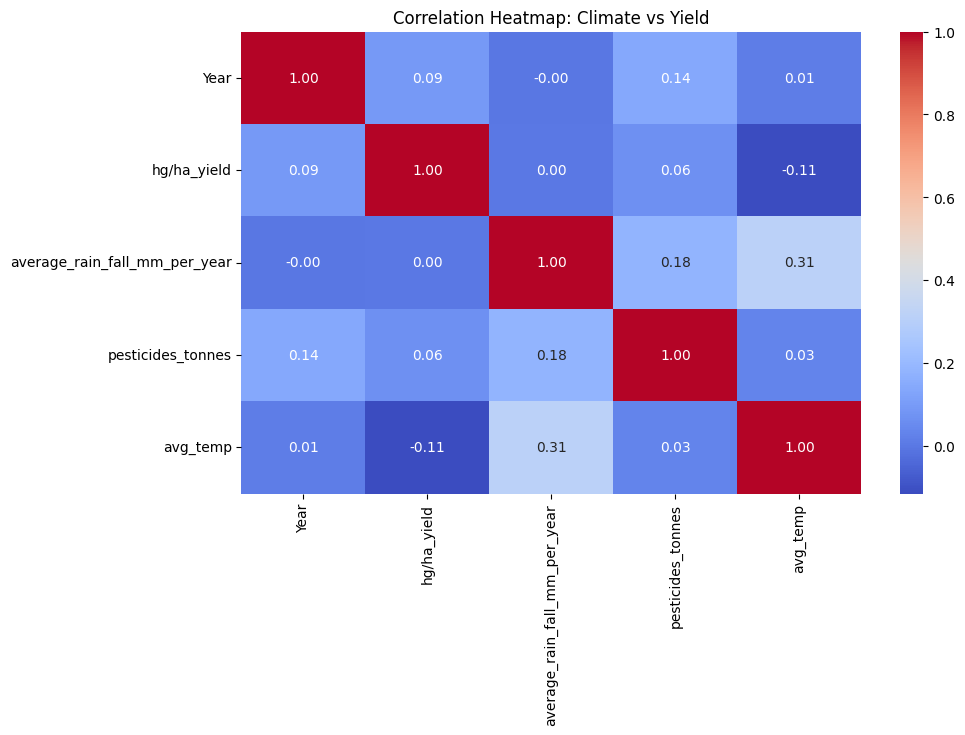

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# We only calculate correlation for numerical columns
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Climate vs Yield')
plt.show()

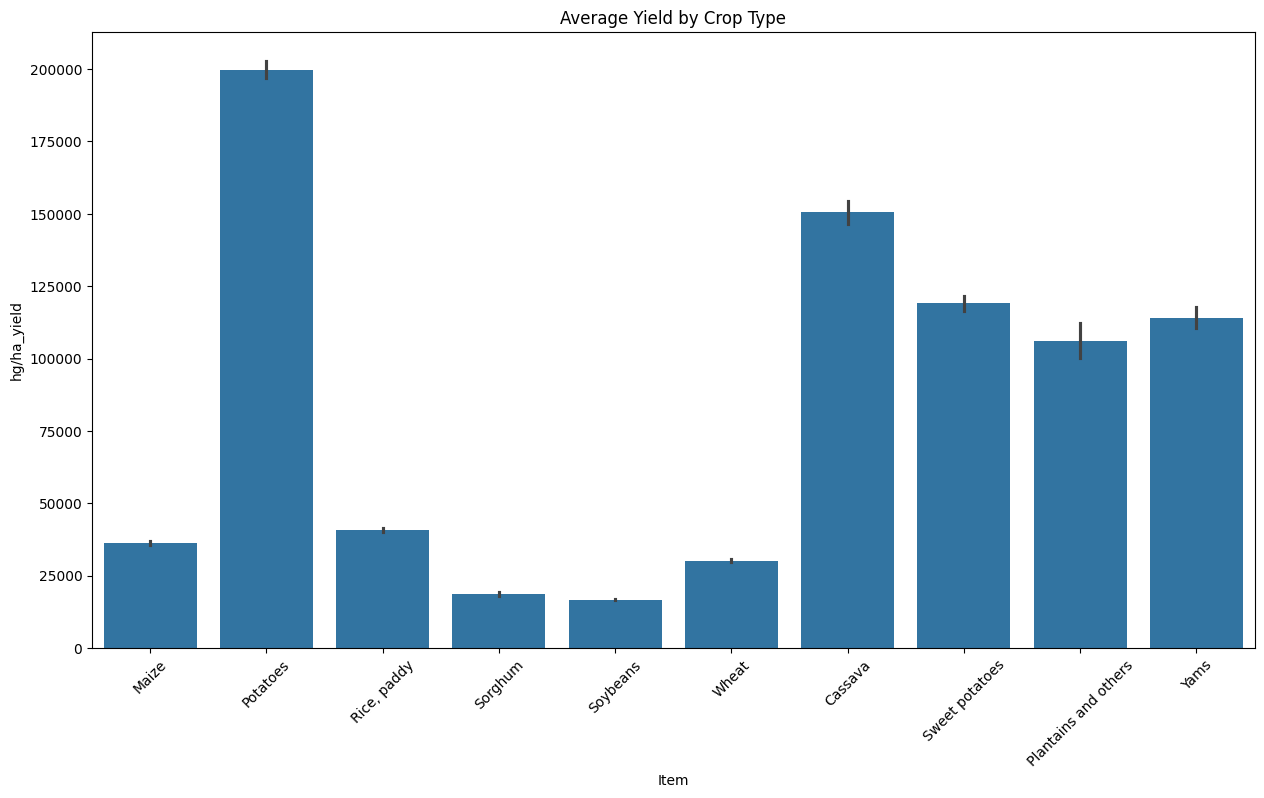

In [24]:
# Visualize Average Yield per Crop
plt.figure(figsize=(15, 8))
sns.barplot(data=df, x='Item', y='hg/ha_yield')
plt.title('Average Yield by Crop Type')
plt.xticks(rotation=45)
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Define the models to compare
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor # Make sure xgboost is installed

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

# 2. Setup the Preprocessing (Scaling numbers & Encoding text)
categorical_cols = ['Area', 'Item']
numerical_cols = ['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# 3. Split the data
X = df.drop('hg/ha_yield', axis=1)
y = df['hg/ha_yield']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Training Loop
comparison_results = []

for name, model in models.items():
    # Create a pipeline for each model
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('regressor', model)])
    
    # Train the model
    clf.fit(X_train, y_train)
    
    # Get predictions
    y_pred = clf.predict(X_test)
    
    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    comparison_results.append({"Model": name, "R2 Score": r2, "MAE": mae})

# Display the results
results_df = pd.DataFrame(comparison_results).sort_values(by="R2 Score", ascending=False)
results_df

,Model,R2 Score,MAE
2,Random Forest,0.987777,3473.479958
1,Decision Tree,0.979740,3677.361834
4,XGBoost,0.975929,7720.577148
3,Gradient Boosting,0.873241,19396.278598
0,Linear Regression,0.755142,29582.509000


In [26]:
import joblib

# 1. Re-train the winning model pipeline on the full training set 
# (We use the pipeline so it includes the scaler and encoder)
best_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

best_model_pipeline.fit(X_train, y_train)

# 2. Save the model file to your 'models' folder
joblib.dump(best_model_pipeline, '../models/crop_yield_model.pkl')

print("Phase 3 Complete: Winning model saved as 'crop_yield_model.pkl' in the models folder.")

Phase 3 Complete: Winning model saved as 'crop_yield_model.pkl' in the models folder.


In [27]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import BaggingRegressor

# Update your models dictionary
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Bagging Regressor": BaggingRegressor(n_estimators=10, random_state=42)
}

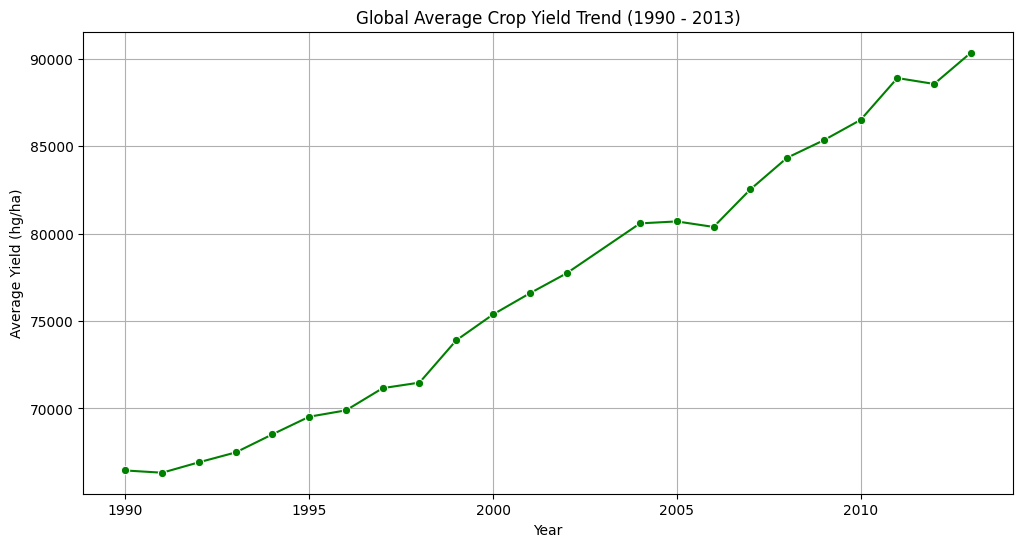

In [28]:
# Grouping data by Year to see Global Yield Trends
plt.figure(figsize=(12, 6))
df_yearly = df.groupby('Year')['hg/ha_yield'].mean().reset_index()
sns.lineplot(data=df_yearly, x='Year', y='hg/ha_yield', marker='o', color='green')
plt.title('Global Average Crop Yield Trend (1990 - 2013)')
plt.ylabel('Average Yield (hg/ha)')
plt.grid(True)
plt.show()

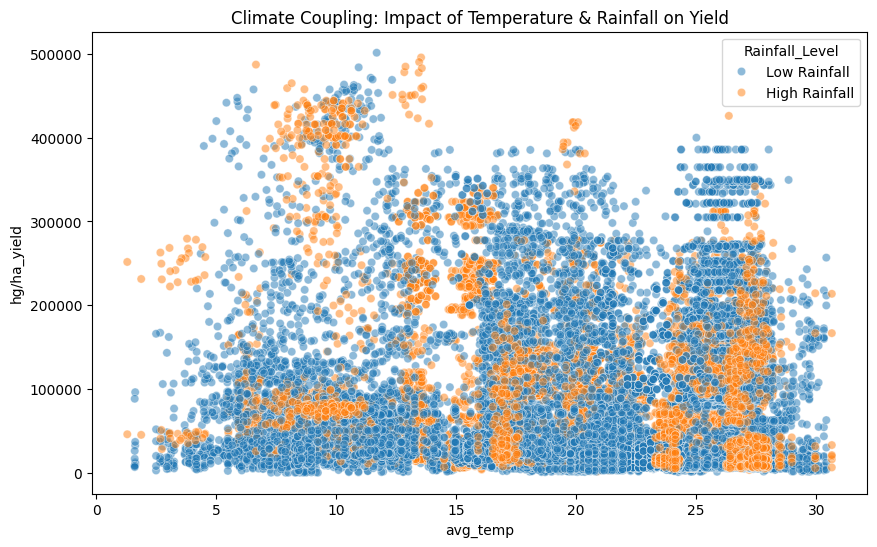

In [29]:
# Visualizing the coupling of Temperature and Rainfall on Yield
plt.figure(figsize=(10, 6))
# We bin rainfall into 'High' and 'Low' for better visualization
df['Rainfall_Level'] = pd.qcut(df['average_rain_fall_mm_per_year'], 2, labels=['Low Rainfall', 'High Rainfall'])

sns.scatterplot(data=df, x='avg_temp', y='hg/ha_yield', hue='Rainfall_Level', alpha=0.5)
plt.title('Climate Coupling: Impact of Temperature & Rainfall on Yield')
plt.show()

In [30]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import BaggingRegressor

# Updated Hybrid Model List as per PPT Scope
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Bagging Regressor": BaggingRegressor(n_estimators=10, random_state=42)
}

# (The rest of your training loop remains the same)

In [31]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import BaggingRegressor

# Expanding the dictionary to match Slide 3 and Slide 8 of your PPT
models["KNN"] = KNeighborsRegressor(n_neighbors=5)
models["Bagging Regressor"] = BaggingRegressor(n_estimators=10, random_state=42)

# Re-run your training loop to update the 'results_df'

In [34]:
from sklearn.pipeline import Pipeline

# 1. We use the same preprocessor you defined earlier
preprocessor = best_model_pipeline.named_steps['preprocessor']

# 2. Train every model in our hybrid dictionary
print("Training the Hybrid Ensemble Framework...")
for name, model in models.items():
    # Create a temporary pipeline for each model
    temp_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    temp_pipe.fit(X_train, y_train)
    print(f"Finished training: {name}")

# 3. Now let's prepare the preprocessed sample data again
X_test_preprocessed = preprocessor.transform(X_test)

# 4. Now run the Agreement Function again
def get_model_agreement(input_data):
    rf_pred = models["Random Forest"].predict(input_data)[0]
    xgb_pred = models["XGBoost"].predict(input_data)[0]
    bag_pred = models["Bagging Regressor"].predict(input_data)[0]
    
    preds = [rf_pred, xgb_pred, bag_pred]
    avg_prediction = np.mean(preds)
    uncertainty = (np.std(preds) / avg_prediction) * 100
    
    return avg_prediction, 100 - uncertainty

# 5. Test it
sample_idx = 0 
sample_data = X_test_preprocessed[sample_idx].reshape(1, -1)
final_val, reliability = get_model_agreement(sample_data)

print("\n--- RESULTS ---")
print(f"Final Predicted Yield: {final_val:.2f} hg/ha")
print(f"Model Agreement Reliability: {reliability:.2f}%")

Training the Hybrid Ensemble Framework...
Finished training: Linear Regression
Finished training: Decision Tree
Finished training: Random Forest
Finished training: Gradient Boosting
Finished training: XGBoost
Finished training: KNN
Finished training: Bagging Regressor

--- RESULTS ---
Final Predicted Yield: 71287.96 hg/ha
Model Agreement Reliability: 99.11%


In [35]:
import joblib

# Save the best pipeline (Random Forest)
joblib.dump(best_model_pipeline, 'crop_yield_model.pkl')

# Save the dictionary of all models for the Agreement Analysis
joblib.dump(models, 'hybrid_framework_models.pkl')

print("All models saved successfully!")

All models saved successfully!


In [37]:
from sklearn.metrics import r2_score

# 1. Initialize the results dictionary
results = {}

print("Evaluating Hybrid Framework Models...")

# 2. Loop through our trained models and calculate R2 scores
for name, model in models.items():
    # Preprocess the test data (if not already done)
    # Note: We use the preprocessor to transform X_test to match the model input
    X_test_preprocessed = preprocessor.transform(X_test)
    
    # Get predictions
    y_pred = model.predict(X_test_preprocessed)
    
    # Calculate R2 Score
    score = r2_score(y_test, y_pred)
    results[name] = score
    print(f"{name}: R2 Score = {score:.4f}")

# 3. Create the final comparison table
results_df = pd.DataFrame({
    'Model': results.keys(),
    'R2 Score': results.values()
}).sort_values(by='R2 Score', ascending=False)

print("\n--- FINAL MODEL COMPARISON ---")
print(results_df)

Evaluating Hybrid Framework Models...
Linear Regression: R2 Score = 0.7551
Decision Tree: R2 Score = 0.9797
Random Forest: R2 Score = 0.9878
Gradient Boosting: R2 Score = 0.8732
XGBoost: R2 Score = 0.9759
KNN: R2 Score = 0.9854
Bagging Regressor: R2 Score = 0.9853

--- FINAL MODEL COMPARISON ---
               Model  R2 Score
2      Random Forest  0.987777
5                KNN  0.985437
6  Bagging Regressor  0.985272
1      Decision Tree  0.979740
4            XGBoost  0.975929
3  Gradient Boosting  0.873241
0  Linear Regression  0.755142


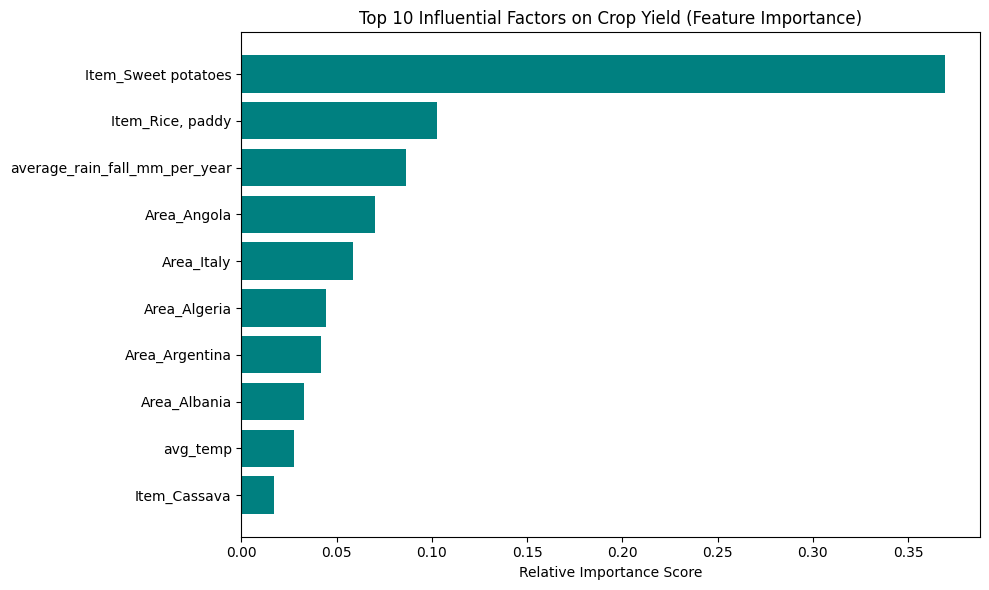

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Access the regressor and preprocessor from the pipeline
rf_model = best_model_pipeline.named_steps['regressor']
preprocessor = best_model_pipeline.named_steps['preprocessor']

# Get feature names after one-hot encoding
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out().tolist()
num_features = ['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
all_features = cat_features + num_features

# Get importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]  # Show top 10 most influential features

plt.figure(figsize=(10, 6))
plt.title('Top 10 Influential Factors on Crop Yield (Feature Importance)')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [all_features[i] for i in indices])
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()

In [39]:
import joblib

# 1. Save the primary prediction pipeline (Random Forest)
joblib.dump(best_model_pipeline, 'crop_yield_model.pkl')

# 2. Save the preprocessor separately (for input transformation)
preprocessor = best_model_pipeline.named_steps['preprocessor']
joblib.dump(preprocessor, 'preprocessor.pkl')

# 3. Save the full hybrid dictionary for 'Model Agreement' checks
joblib.dump(models, 'hybrid_framework_models.pkl')

print("Deployment assets saved: model.pkl, preprocessor.pkl, framework.pkl")

Deployment assets saved: model.pkl, preprocessor.pkl, framework.pkl


In [40]:
print("Countries:", sorted(df['Area'].unique()))
print("Crops:", sorted(df['Item'].unique()))

Countries: ['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Belarus', 'Belgium', 'Botswana', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cameroon', 'Canada', 'Central African Republic', 'Chile', 'Colombia', 'Croatia', 'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Eritrea', 'Estonia', 'Finland', 'France', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Guinea', 'Guyana', 'Haiti', 'Honduras', 'Hungary', 'India', 'Indonesia', 'Iraq', 'Ireland', 'Italy', 'Jamaica', 'Japan', 'Kazakhstan', 'Kenya', 'Latvia', 'Lebanon', 'Lesotho', 'Libya', 'Lithuania', 'Madagascar', 'Malawi', 'Malaysia', 'Mali', 'Mauritania', 'Mauritius', 'Mexico', 'Montenegro', 'Morocco', 'Mozambique', 'Namibia', 'Nepal', 'Netherlands', 'New Zealand', 'Nicaragua', 'Niger', 'Norway', 'Pakistan', 'Papua New Guinea', 'Peru', 'Poland', 'Portugal', 'Qatar', 'Romania', 'Rwanda', 'Saudi Arabia', 'Senegal', 'Slovenia', 'South 